In [1]:
import torch
import pandas as pd
import itertools
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
train_price = pd.read_csv("train_price.csv", index_col="Date", parse_dates=True)['BTC-USD']
test_price = pd.read_csv("test_price.csv", index_col="Date", parse_dates=True)['BTC-USD']
# Remove the first two rows and reset the index
X_train = X_train.iloc[2:].reset_index(drop=True)
# Rename the "Price" column to "Date"
X_train.rename(columns={"Price": "Date"}, inplace=True)
# Convert the "Date" column to datetime format
X_train["Date"] = pd.to_datetime(X_train["Date"])
# Set "Date" as the index
X_train.set_index("Date", inplace=True)
# Remove the first two rows and reset the index
X_test = X_test.iloc[2:].reset_index(drop=True)
# Rename the "Price" column to "Date"
X_test.rename(columns={"Price": "Date"}, inplace=True)
# Convert the "Date" column to datetime format
X_test["Date"] = pd.to_datetime(X_test["Date"])
# Set "Date" as the index
X_test.set_index("Date", inplace=True)
# Robust scaling
scaler = RobustScaler()
X_train_scaled_array = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled_array, index=X_train.index, columns=X_train.columns)

X_test_scaled_array = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled_array, index=X_test.index, columns=X_test.columns)

# Define features
from itertools import combinations
features = [
    list(comb)
    for r in range(1, len(X_train.columns) + 1)
    for comb in combinations(X_train.columns, r)
]

In [3]:
X_train.head()

,Returns,Range,Log_Range,pct_Range,fg,pct_fg,RSI,pct_RSI
Date,,,,,,,,
2018-02-16,0.006618,0.050818,0.049569,-0.431059,67.0,-0.056338,63.799058,0.007788
2018-02-17,0.082383,0.097553,0.093083,0.919639,74.0,0.104478,69.537696,0.089949
2018-02-18,-0.051792,0.099148,0.094535,0.016353,63.0,-0.148649,62.705291,-0.098255
2018-02-19,0.061874,0.072347,0.069850,-0.270310,67.0,0.063492,66.909576,0.067048
2018-02-20,0.015768,0.064700,0.062693,-0.105697,74.0,0.104478,67.940541,0.015408


In [7]:
def create_feature_combinations(columns):
    """
    Create all possible feature combinations from the given columns.
    
    Parameters:
    -----------
    columns : list
        List of column names
        
    Returns:
    --------
    list
        List of feature combinations (each as a list)
    """
    features = []
    for r in range(1, len(columns) + 1):
        combinations = [list(combo) for combo in itertools.combinations(columns, r)]
        features.extend(combinations)
    return features

# Function to visualize regimes
def visualize_regimes(regimes, prices, title="Market Regimes"):
    """
    Visualize regimes with prices.
    
    Parameters:
    -----------
    regimes : numpy.ndarray
        Predicted regimes
    prices : pandas.Series
        Price data with datetime index
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with regime visualization
    """
    # Create DataFrame with price and regime data
    df = pd.DataFrame({
        'Price': prices,
        'Regime': regimes
    }, index=prices.index)
    
    # Count unique regimes
    n_regimes = len(np.unique(regimes))
    
    # Create figure and axes
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Plot prices
    ax1.plot(df.index, df['Price'], color='black', alpha=0.6, linewidth=1, label='Price')
    ax1.set_ylabel('Price', fontsize=12)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.grid(True, alpha=0.3)
    
    # Get colors for regimes
    colors = plt.cm.tab10(np.linspace(0, 1, n_regimes))
    
    # Create background colors for regimes
    prev_regime = regimes[0]
    start_idx = 0
    
    for i, regime in enumerate(regimes):
        if regime != prev_regime or i == len(regimes) - 1:
            # Mark end of previous regime
            end_idx = i-1 if regime != prev_regime else i
            # Color region based on regime
            plt.axvspan(df.index[start_idx], df.index[end_idx], 
                        alpha=0.3, color=colors[prev_regime], label=f'Regime {prev_regime}')
            # Start new region
            start_idx = i
            prev_regime = regime
    
    # Handle legend with unique labels
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='upper left')
    
    plt.title(title, fontsize=14)
    plt.tight_layout()
    
    return fig

# Function to analyze returns by regime
def analyze_returns_by_regime(X_test, regimes, title="Returns by Regime"):
    """
    Create visualizations for analyzing returns by regime.
    
    Parameters:
    -----------
    X_test : pandas.DataFrame
        Test data with returns
    regimes : numpy.ndarray
        Predicted regimes
    title : str
        Plot title
        
    Returns:
    --------
    matplotlib.figure.Figure
        Figure with returns analysis
    """
    # Create a DataFrame with regimes and returns
    regime_returns = pd.DataFrame({
        'Regime': regimes,
        'Returns': X_test['Returns']
    }, index=X_test.index)
    
    # Calculate statistics for each regime
    regime_stats = regime_returns.groupby('Regime')['Returns'].agg([
        ('Mean', 'mean'),
        ('Median', 'median'),
        ('Std', 'std'),
        ('Min', 'min'),
        ('Max', 'max'),
        ('Count', 'count')
    ])
    
    # Calculate average returns and volatility
    regime_stats['Mean_Pct'] = regime_stats['Mean'] * 100
    regime_stats['Std_Pct'] = regime_stats['Std'] * 100
    
    # Calculate percentage of days in each regime
    total_days = len(regime_returns)
    regime_stats['Percentage'] = (regime_stats['Count'] / total_days) * 100
    
    # Create figure with multiple subplots
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)
    
    # 1. Box plot of returns by regime
    sns.boxplot(x='Regime', y='Returns', data=regime_returns, ax=axs[0, 0])
    axs[0, 0].set_title('Distribution of Returns by Regime', fontsize=14)
    axs[0, 0].set_ylabel('Returns', fontsize=12)
    axs[0, 0].set_xlabel('Regime', fontsize=12)
    axs[0, 0].axhline(y=0, color='r', linestyle='-', alpha=0.3)
    
    # 2. Bar chart of average returns by regime
    regime_indices = regime_stats.index
    colors = ['red' if x < 0 else 'green' for x in regime_stats['Mean_Pct']]
    axs[0, 1].bar(regime_indices, regime_stats['Mean_Pct'], color=colors)
    axs[0, 1].set_title('Average Returns by Regime (%)', fontsize=14)
    axs[0, 1].set_ylabel('Average Return (%)', fontsize=12)
    axs[0, 1].set_xlabel('Regime', fontsize=12)
    axs[0, 1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(regime_stats['Mean_Pct']):
        axs[0, 1].text(i, v + (0.1 if v >= 0 else -0.1), 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 3. Returns volatility (std) by regime
    axs[1, 0].bar(regime_indices, regime_stats['Std_Pct'], color='blue', alpha=0.7)
    axs[1, 0].set_title('Return Volatility by Regime (%)', fontsize=14)
    axs[1, 0].set_ylabel('Standard Deviation of Returns (%)', fontsize=12)
    axs[1, 0].set_xlabel('Regime', fontsize=12)
    
    # Add value labels on bars
    for i, v in enumerate(regime_stats['Std_Pct']):
        axs[1, 0].text(i, v + 0.1, 
                    f"{v:.2f}%", 
                    ha='center', 
                    fontsize=10,
                    fontweight='bold')
    
    # 4. Regime distribution pie chart
    explode = [0.1] * len(regime_indices)  # explode all slices
    axs[1, 1].pie(regime_stats['Percentage'], explode=explode, 
                labels=[f"Regime {i}" for i in regime_indices], 
                autopct='%1.1f%%', shadow=True, startangle=90)
    axs[1, 1].set_title('Distribution of Regimes', fontsize=14)
    
    # Print statistics table
    print("\nRegime Statistics:")
    print(regime_stats.round(4))
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to accommodate suptitle
    
    return fig# PyTorch DNN-HMM Analysis for Bitcoin Market Regimes

# Import necessary libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import silhouette_score
import itertools
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

# Create output directory for saved figures
os.makedirs("dnn_hmm_output", exist_ok=True)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("PyTorch DNN-HMM Analysis for Bitcoin Market Regimes")
print("=" * 60)

# Define Feature Extractor (Neural Network) class
class FeatureExtractor(nn.Module):
    """
    Neural network for feature extraction in PyTorch.
    """
    def __init__(self, input_dim, hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2):
        super(FeatureExtractor, self).__init__()
        
        # Build layers
        layers = []
        prev_dim = input_dim
        
        # Add hidden layers
        for dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, dim))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = dim
        
        # Add embedding layer
        layers.append(nn.Linear(prev_dim, embedding_dim))
        layers.append(nn.Tanh())
        
        # Combine layers
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

# Define Hidden Markov Model class
class HMM:
    """
    Hidden Markov Model implementation using PyTorch.
    """
    def __init__(self, n_states, n_dims, init_type='random'):
        self.n_states = n_states
        self.n_dims = n_dims
        
        # Initialize parameters
        if init_type == 'random':
            # Initial state probabilities (pi)
            self.log_pi = nn.Parameter(torch.randn(n_states).float())
            
            # Transition matrix (A)
            self.log_A = nn.Parameter(torch.randn(n_states, n_states).float())
            
            # Emission parameters for Gaussian emissions
            self.means = nn.Parameter(torch.randn(n_states, n_dims).float())
            # Use log scale for numerical stability
            self.log_vars = nn.Parameter(torch.randn(n_states, n_dims).float())
        else:
            # More stable initialization
            # Initial state probabilities (pi) - uniform
            self.log_pi = torch.log(torch.ones(n_states) / n_states)
            
            # Transition matrix (A) - slightly biased to stay in same state
            A = torch.ones(n_states, n_states) * 0.1
            for i in range(n_states):
                A[i, i] = 0.8  # High self-transition probability
            A = A / A.sum(dim=1, keepdim=True)  # Normalize rows
            self.log_A = torch.log(A)
            
            # Emission parameters - spread out means
            self.means = torch.zeros(n_states, n_dims)
            for i in range(n_states):
                self.means[i] = torch.randn(n_dims) * 2.0 + i  # Separated means
            
            # Start with unit variance
            self.log_vars = torch.zeros(n_states, n_dims)
    
    def normalize_parameters(self):
        """Normalize parameters to ensure valid probabilities."""
        # Normalize initial state probabilities
        log_pi_norm = self.log_pi - torch.logsumexp(self.log_pi, dim=0)
        
        # Normalize transition probabilities
        log_A_norm = self.log_A - torch.logsumexp(self.log_A, dim=1, keepdim=True)
        
        return log_pi_norm, log_A_norm
    
    def emission_log_probs(self, x):
        """
        Calculate emission log probabilities for all states and observations.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
            
        Returns:
        --------
        torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
        """
        batch_size = x.shape[0]
        log_emissions = torch.zeros(batch_size, self.n_states)
        
        for j in range(self.n_states):
            # Calculate Gaussian log probability
            vars_j = torch.exp(self.log_vars[j])
            diff = x - self.means[j]
            log_p = -0.5 * (torch.log(2 * np.pi * vars_j) + (diff ** 2) / vars_j)
            log_emissions[:, j] = log_p.sum(dim=1)
        
        return log_emissions
    
    def viterbi_algorithm(self, log_emissions):
        """
        Viterbi algorithm to find the most likely state sequence.
        
        Parameters:
        -----------
        log_emissions : torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
            
        Returns:
        --------
        torch.Tensor
            Most likely state sequence, shape (batch_size)
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize Viterbi variables
        delta = torch.zeros(batch_size, self.n_states)
        psi = torch.zeros(batch_size, self.n_states, dtype=torch.long)
        
        # Initialization
        delta[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                probs = delta[t-1] + log_A_norm[:, j]
                psi[t, j] = torch.argmax(probs)
                delta[t, j] = probs[psi[t, j]] + log_emissions[t, j]
        
        # Backtracking
        states = torch.zeros(batch_size, dtype=torch.long)
        states[-1] = torch.argmax(delta[-1])
        
        for t in range(batch_size-2, -1, -1):
            states[t] = psi[t+1, states[t+1]]
        
        return states
    
    def forward_algorithm(self, log_emissions):
        """
        Forward algorithm to calculate log-likelihood.
        
        Parameters:
        -----------
        log_emissions : torch.Tensor
            Log emission probabilities, shape (batch_size, n_states)
            
        Returns:
        --------
        torch.Tensor
            Log-likelihood
        """
        batch_size = log_emissions.shape[0]
        
        # Normalize parameters
        log_pi_norm, log_A_norm = self.normalize_parameters()
        
        # Initialize forward variables
        log_alpha = torch.zeros(batch_size, self.n_states)
        
        # Initialization
        log_alpha[0] = log_pi_norm + log_emissions[0]
        
        # Recursion
        for t in range(1, batch_size):
            for j in range(self.n_states):
                log_alpha[t, j] = torch.logsumexp(log_alpha[t-1] + log_A_norm[:, j], dim=0) + log_emissions[t, j]
        
        # Calculate log-likelihood
        log_likelihood = torch.logsumexp(log_alpha[-1], dim=0)
        
        return log_likelihood
    
    def fit(self, x, max_iter=100, tol=1e-6):
        """
        Fit the HMM using Baum-Welch algorithm.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
        max_iter : int
            Maximum number of iterations
        tol : float
            Convergence tolerance
            
        Returns:
        --------
        float
            Log-likelihood
        """
        prev_ll = -float('inf')
        
        for iteration in range(max_iter):
            # E-step: Calculate log emission probabilities
            log_emissions = self.emission_log_probs(x)
            
            # Calculate log-likelihood
            log_likelihood = self.forward_algorithm(log_emissions)
            
            # Check convergence
            if log_likelihood - prev_ll < tol:
                break
                
            prev_ll = log_likelihood
            
            # M-step: Need to implement a proper Baum-Welch algorithm here
            # This is a simplified version that just updates means and variances
            
            # Get state assignments (hard assignment for simplicity)
            states = self.viterbi_algorithm(log_emissions)
            
            # Update emission parameters
            for j in range(self.n_states):
                mask = (states == j)
                if mask.sum() > 0:
                    # Update means
                    self.means[j] = x[mask].mean(dim=0)
                    # Update variances (with minimum variance for stability)
                    vars_j = torch.clamp(((x[mask] - self.means[j]) ** 2).mean(dim=0), min=1e-6)
                    self.log_vars[j] = torch.log(vars_j)
            
            # Update transition parameters (simplified)
            state_transitions = torch.zeros((self.n_states, self.n_states))
            for t in range(1, len(states)):
                state_transitions[states[t-1], states[t]] += 1
                
            # Add small value to prevent zeros and normalize
            state_transitions = state_transitions + 1e-6
            state_transitions = state_transitions / state_transitions.sum(dim=1, keepdim=True)
            self.log_A = torch.log(state_transitions)
        
        return log_likelihood.item()
    
    def predict(self, x):
        """
        Predict states using Viterbi algorithm.
        
        Parameters:
        -----------
        x : torch.Tensor
            Observations, shape (batch_size, n_dims)
            
        Returns:
        --------
        numpy.ndarray
            Predicted states
        """
        log_emissions = self.emission_log_probs(x)
        states = self.viterbi_algorithm(log_emissions)
        return states.numpy()

# Function to train neural network
def train_neural_network(X, hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2, 
                        learning_rate=0.001, epochs=100, batch_size=32):
    """
    Train the neural network feature extractor using PyTorch.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Input features
    hidden_dims, embedding_dim, dropout_rate : model parameters
    learning_rate : float
        Learning rate for the optimizer
    epochs : int
        Number of training epochs
    batch_size : int
        Batch size for training
        
    Returns:
    --------
    tuple
        (trained model, embeddings)
    """
    # Convert to PyTorch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    
    # Create dataset and dataloader
    dataset = TensorDataset(X_tensor, X_tensor)  # Self-supervised
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Create model
    model = FeatureExtractor(
        input_dim=X.shape[1], 
        hidden_dims=hidden_dims, 
        embedding_dim=embedding_dim, 
        dropout_rate=dropout_rate
    )
    
    # Define loss and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    for epoch in range(epochs):
        total_loss = 0
        for inputs, targets in dataloader:
            # Forward pass
            outputs = model(inputs)
            
            # Loss calculation - reconstruction loss (MSE between output and input)
            loss = criterion(outputs, inputs)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        # Early stopping could be implemented here
        if epoch % 10 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")
            
            # Early stopping check could go here
    
    # Generate embeddings
    model.eval()
    with torch.no_grad():
        embeddings = model(X_tensor).numpy()
    
    return model, embeddings

# Function to train DNN-HMM
def train_pytorch_dnn_hmm(X_subset, is_scaled, n_states=3, hidden_dims=[64, 32], embedding_dim=16, 
                        dropout_rate=0.2, learning_rate=0.001, epochs=100, batch_size=32):
    """
    Train a DNN-HMM model using PyTorch.
    
    Parameters:
    -----------
    X_subset : numpy.ndarray
        Feature data subset
    is_scaled : bool
        Whether the data is already scaled
    n_states, hidden_dims, embedding_dim, etc. : model parameters
        
    Returns:
    --------
    tuple
        (trained_model, log_likelihood, regimes)
    """
    print(f"  Training PyTorch DNN-HMM with X_subset shape: {X_subset.shape}")
    
    # Scale the data if needed
    if not is_scaled:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_subset)
    else:
        scaler = None
        X_scaled = X_subset
    
    # Train neural network and get embeddings
    nn_model, embeddings = train_neural_network(
        X_scaled, 
        hidden_dims=hidden_dims,
        embedding_dim=embedding_dim,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        epochs=epochs,
        batch_size=batch_size
    )
    
    # Create and train HMM
    hmm_model = HMM(n_states=n_states, n_dims=embedding_dim, init_type='stable')
    
    # Convert embeddings to PyTorch tensor
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
    
    # Train the HMM
    log_likelihood = hmm_model.fit(embeddings_tensor)
    
    # Get state predictions
    regimes = hmm_model.predict(embeddings_tensor)
    
    # Create a composite model containing all necessary components
    model = {
        'hmm_model': hmm_model,
        'nn_model': nn_model,
        'scaler': scaler,
        'input_dim': X_subset.shape[1],
        'embedding_dim': embedding_dim
    }
    
    return model, log_likelihood, regimes

# Function to make predictions
def predict_pytorch_dnn_hmm(model, X_subset):
    """
    Make predictions with a trained PyTorch DNN-HMM model.
    
    Parameters:
    -----------
    model : dict
        Trained model components
    X_subset : numpy.ndarray
        Feature data subset
        
    Returns:
    --------
    numpy.ndarray
        Predicted regimes
    """
    # Extract model components
    hmm_model = model['hmm_model']
    nn_model = model['nn_model']
    scaler = model['scaler']
    
    # Scale the data if needed
    if scaler is not None:
        X_scaled = scaler.transform(X_subset)
    else:
        X_scaled = X_subset
    
    # Convert to PyTorch tensor
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    
    # Generate embeddings
    nn_model.eval()
    with torch.no_grad():
        embeddings = nn_model(X_tensor)
    
    # Make predictions
    try:
        regimes = hmm_model.predict(embeddings)
        return regimes
    except Exception as e:
        print(f"  Error in prediction: {str(e)}")
        # Return default predictions in case of error
        return np.zeros(X_subset.shape[0], dtype=int)

# Function to calculate silhouette score
def calculate_silhouette(X_subset, regimes):
    """
    Calculate silhouette score or alternative metric for single feature case.
    
    Parameters:
    -----------
    X_subset : numpy.ndarray
        Feature data subset
    regimes : numpy.ndarray
        Predicted regimes from the model
        
    Returns:
    --------
    float or None
        Silhouette score or alternative metric, None if calculation fails
    """
    # Quick checks before expensive computation
    # Check if we have enough unique regimes
    unique_regimes = np.unique(regimes)
    if len(unique_regimes) <= 1:
        return 0.0
    
    # Special handling for 1D data
    n_features = X_subset.shape[1] if X_subset.ndim > 1 else 1
    
    # For multi-feature data, try standard silhouette score
    if n_features > 1:
        try:
            return silhouette_score(X_subset, regimes)
        except Exception as e:
            print(f"Silhouette score calculation failed: {str(e)}")
            return None
    else:
        # For 1D data, use simplified variance ratio calculation
        try:
            # Reshape 1D data if needed
            X_flat = X_subset.flatten() if X_subset.ndim > 1 else X_subset
            
            # Get overall mean
            overall_mean = np.mean(X_flat)
            overall_var = np.var(X_flat)
            
            if overall_var < 1e-10:  # Effectively zero variance
                return 0.0
            
            # Calculate between and within variance
            between_var = 0
            within_var = 0
            
            # Calculate weighted means and variances for each regime
            for regime in unique_regimes:
                mask = (regimes == regime)
                count = np.sum(mask)
                if count > 0:
                    regime_data = X_flat[mask]
                    regime_mean = np.mean(regime_data)
                    regime_var = np.var(regime_data)
                    
                    # Update between variance
                    between_var += count * (regime_mean - overall_mean) ** 2
                    
                    # Update within variance
                    within_var += count * regime_var
            
            # Normalize by sample size
            between_var /= len(X_flat)
            within_var /= len(X_flat)
            
            # Handle edge cases
            if within_var < 1e-10:  # Effectively zero within-variance
                return 1.0 if between_var > 0 else 0.0
            
            # Calculate ratio and transform to [-1, 1] range
            ratio = between_var / (between_var + within_var)
            return 2 * ratio - 1
            
        except Exception as e:
            print(f"Alternative silhouette calculation failed: {str(e)}")
            return None
            
# Function to train multiple models with different feature combinations
def train_pytorch_dnn_hmm_model(X_train, X_train_scaled, features, model_name="PyTorchDNNHMM", n_states=3, 
                              hidden_dims=[64, 32], embedding_dim=16, dropout_rate=0.2,
                              learning_rate=0.001, epochs=100, batch_size=32):
    """
    Train PyTorch DNN-HMM models for all feature combinations.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Raw training data
    X_train_scaled : pandas.DataFrame
        Scaled training data
    features : list of lists
        Feature combinations to use
    model_name, n_states, hidden_dims, etc. : model parameters
        
    Returns:
    --------
    dict
        Dictionary of model information (models_info)
    """
    models_info = {}
    model_id_counter = 0
    
    # Process for both scaling options
    for is_scaled in [False, True]:
        # Select appropriate data
        X = X_train_scaled if is_scaled else X_train
        scaling_name = "robust" if is_scaled else "none"
        
        print(f"\nTraining {model_name} models with {scaling_name} scaling")
        
        # Process each feature combination
        for feature_list in tqdm(features, desc=f"Training models ({scaling_name} scaling)"):
            feature_name = "+".join(feature_list)
            
            try:
                # Extract data for this feature combination
                X_subset = X[feature_list].values
                
                # Train the model
                start_time = time.time()
                model, log_likelihood, regimes = train_pytorch_dnn_hmm(
                    X_subset, 
                    is_scaled,
                    n_states=n_states,
                    hidden_dims=hidden_dims,
                    embedding_dim=embedding_dim,
                    dropout_rate=dropout_rate,
                    learning_rate=learning_rate,
                    epochs=epochs,
                    batch_size=batch_size
                )
                processing_time = time.time() - start_time
                
                # Calculate silhouette score
                silhouette = calculate_silhouette(X_subset, regimes)
                
                # Generate unique model ID
                model_id = f"{model_name}_{scaling_name}_{feature_name}_{model_id_counter}"
                model_id_counter += 1
                
                # Store model information
                models_info[model_id] = {
                    'model': model,
                    'model_type': model_name,
                    'scaling': scaling_name,
                    'features': feature_list,
                    'silhouette_score': silhouette,
                    'log_likelihood': log_likelihood,
                    'regimes': regimes,
                    'processing_time': processing_time
                }
                
                # Debug output
                print(f"Trained model with features {feature_list}, silhouette: {silhouette}, log-likelihood: {log_likelihood}")
                
            except Exception as e:
                print(f"Error training model with features {feature_list}, scaling {scaling_name}: {str(e)}")
    
    return models_info
    
# Function to predict with a specific model
def predict_with_model(models_info, model_id, X_new):
    """
    Make predictions with a specific model.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary containing all trained models
    model_id : str
        ID of the model to use for prediction
    X_new : pandas.DataFrame
        New data for prediction
        
    Returns:
    --------
    numpy.ndarray
        Predicted regimes
    """
    if model_id not in models_info:
        raise ValueError(f"Model ID {model_id} not found")
    
    # Get model information
    model_info = models_info[model_id]
    model = model_info['model']
    features = model_info['features']
    
    # Extract features for prediction
    X_subset = X_new[features].values
    
    # Make prediction
    return predict_pytorch_dnn_hmm(model, X_subset)

# Function to get best models
def get_best_models(models_info, metric='silhouette_score', top_n=5, min_features=1, max_features=None):
    """
    Get the best performing models based on a specified metric.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary containing all trained models
    metric : str
        Metric to use for ranking ('silhouette_score' or 'log_likelihood')
    top_n : int
        Number of top models to return
    min_features, max_features : feature count constraints
        
    Returns:
    --------
    list
        List of (model_id, score) tuples sorted by score
    """
    # Filter models by feature count
    filtered_models = []
    
    for model_id, info in models_info.items():
        feature_count = len(info['features'])
        if feature_count >= min_features and (max_features is None or feature_count <= max_features):
            # Check if the metric exists and is not None
            if metric in info and info[metric] is not None:
                filtered_models.append((model_id, info[metric]))
    
    # Sort by metric (higher is better for silhouette, log_likelihood)
    sorted_models = sorted(filtered_models, key=lambda x: x[1], reverse=True)
    
    # Return top N models
    return sorted_models[:top_n]

# Function to export results
def export_results(models_info, filename):
    """
    Export key results in a format suitable for analysis.
    Creates a CSV file with model results.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary containing all trained models
    filename : str
        File path to save the results
        
    Returns:
    --------
    bool
        Success status
    """
    try:
        # Create results dataframe
        results = []
        
        for model_id, info in models_info.items():
            # Extract basic information
            result = {
                'model_id': model_id,
                'model_type': info['model_type'],
                'scaling': info['scaling'],
                'features': '+'.join(info['features']),
                'feature_count': len(info['features']),
                'silhouette_score': info['silhouette_score'],
                'log_likelihood': info['log_likelihood'],
                'processing_time': info.get('processing_time', None)
            }
            
            results.append(result)
        
        # Convert to dataframe and save
        df = pd.DataFrame(results)
        df.to_csv(filename, index=False)
        
        print(f"Exported {len(results)} model results to {filename}")
        return True
    except Exception as e:
        print(f"Error exporting results: {str(e)}")
        return False

# Function to create dummy HMM object
def create_dummy_hmm_object(models_info, model_name="PyTorchDNNHMM", n_states=3):
    """
    Create a dummy object that mimics a BaseHMMModel instance.
    This allows us to use the existing HMMLeaderboard and HMMVisualizer classes.
    
    Parameters:
    -----------
    models_info : dict
        Dictionary of model information from train_pytorch_dnn_hmm_model()
    model_name : str
        Name for this model type
    n_states : int
        Number of hidden states
        
    Returns:
    --------
    object
        An object with the necessary attributes to work with leaderboard/visualizer
    """
    class DummyHMM:
        def __init__(self, models_info, model_name, n_states):
            self.models_info = models_info
            self.model_name = model_name
            self.n_states = n_states
            
        def predict_with_model(self, model_id, X_new):
            """Forward the prediction to our function"""
            return predict_with_model(self.models_info, model_id, X_new)
    
    return DummyHMM(models_info, model_name, n_states)

# Function to create feature combinations
def create_feature_combinations(columns):
    """
    Create all possible feature combinations from the given columns.
    
    Parameters:
    -----------
    columns : list
        List of column names
        
    Returns:
    --------
    list
        List of feature combinations (each as a list)
    """
    features = []
    for r in range(1, len(columns) + 1):
        combinations = [list(combo) for combo in itertools.combinations(columns, r)]
        features.extend(combinations)
    return features

PyTorch DNN-HMM Analysis for Bitcoin Market Regimes



Selected features for analysis: ['Returns', 'Range', 'Log_Range', 'pct_Range', 'fg', 'pct_fg', 'RSI', 'pct_RSI']

----- Creating Feature Combinations -----
Created 255 feature combinations

----- Training PyTorch DNN-HMM Models -----

Training PyTorchDNNHMM models with none scaling


Training models (none scaling):   0%|                                                          | 0/255 [00:00<?, ?it/s]

  Training PyTorch DNN-HMM with X_subset shape: (2058, 1)


C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 1])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([10, 1])) that is different to the input size (torch.Size([10, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0, Loss: 0.767980
Epoch 10, Loss: 0.353696
Epoch 20, Loss: 0.338840
Epoch 30, Loss: 0.329068
Epoch 40, Loss: 0.331428


...

C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 6])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 6])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
C:\Users\gpari\AppData\Roaming\Python\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([32, 6])) that is different to the input size (torch.Size([32, 8])). This will likely lead to incorrect results due to broa

Error training model with features ['Range', 'Log_Range', 'pct_Range', 'fg', 'pct_fg', 'pct_RSI'], scaling robust: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1
  Training PyTorch DNN-HMM with X_subset shape: (2058, 6)
Error training model with features ['Range', 'Log_Range', 'pct_Range', 'fg', 'RSI', 'pct_RSI'], scaling robust: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1
  Training PyTorch DNN-HMM with X_subset shape: (2058, 6)
Error training model with features ['Range', 'Log_Range', 'pct_Range', 'pct_fg', 'RSI', 'pct_RSI'], scaling robust: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1
  Training PyTorch DNN-HMM with X_subset shape: (2058, 6)
Error training model with features ['Range', 'Log_Range', 'fg', 'pct_fg', 'RSI', 'pct_RSI'], scaling robust: The size of tensor a (8) must match the size of tensor b (6) at non-singleton dimension 1
  Training PyT

Training models (robust scaling): 100%|██████████████████████████████████████████████| 255/255 [02:38<00:00,  1.61it/s]

Trained model with features ['Returns', 'Range', 'Log_Range', 'pct_Range', 'fg', 'pct_fg', 'RSI', 'pct_RSI'], silhouette: 0.0, log-likelihood: -14922.3935546875

----- Finding Best Models -----
Best models by silhouette score:
1. PyTorchDNNHMM_none_RSI_6: score=0.6206, features=['RSI'], scaling=none
2. PyTorchDNNHMM_robust_fg_13: score=0.2833, features=['fg'], scaling=robust
3. PyTorchDNNHMM_none_Log_Range_2: score=0.1559, features=['Log_Range'], scaling=none

Best models by log-likelihood:
1. PyTorchDNNHMM_none_RSI_6: log-likelihood=3997.8650, features=['RSI'], scaling=none
2. PyTorchDNNHMM_none_pct_Range_3: log-likelihood=-2110.3274, features=['pct_Range'], scaling=none
3. PyTorchDNNHMM_none_fg_4: log-likelihood=-4147.3428, features=['fg'], scaling=none

----- Making Predictions with Best Model -----
Using model PyTorchDNNHMM_none_RSI_6 with features: ['RSI']

----- Visualizing Regimes -----
Visualizing training regimes...


Saved training regimes visualization to dnn_hmm_output/train_regimes_RSI.png
Visualizing test regimes...
Saved test regimes visualization to dnn_hmm_output/test_regimes_RSI.png

----- Analyzing Returns by Regime -----

Regime Statistics:
          Mean  Median     Std     Min     Max  Count  Mean_Pct  Std_Pct  \
Regime                                                                     
0       0.0007 -0.0004  0.0260 -0.0871  0.1146    261    0.0725   2.5972   
1      -0.0141 -0.0112  0.0250 -0.0908  0.0371     93   -1.4057   2.5000   
2       0.0135  0.0085  0.0253 -0.0686  0.0981    161    1.3486   2.5312   

        Percentage  
Regime              
0          50.6796  
1          18.0583  
2          31.2621  
Saved returns analysis to dnn_hmm_output/returns_by_regime_RSI.png

Test Data Regime Distribution:
  Regime 0: 261 samples (50.7%)
  Regime 1: 93 samples (18.1%)
  Regime 2: 161 samples (31.3%)

Average Returns by Regime:
  Regime 0: 0.0725%
  Regime 1: -1.4057%
  Regime 2: 1

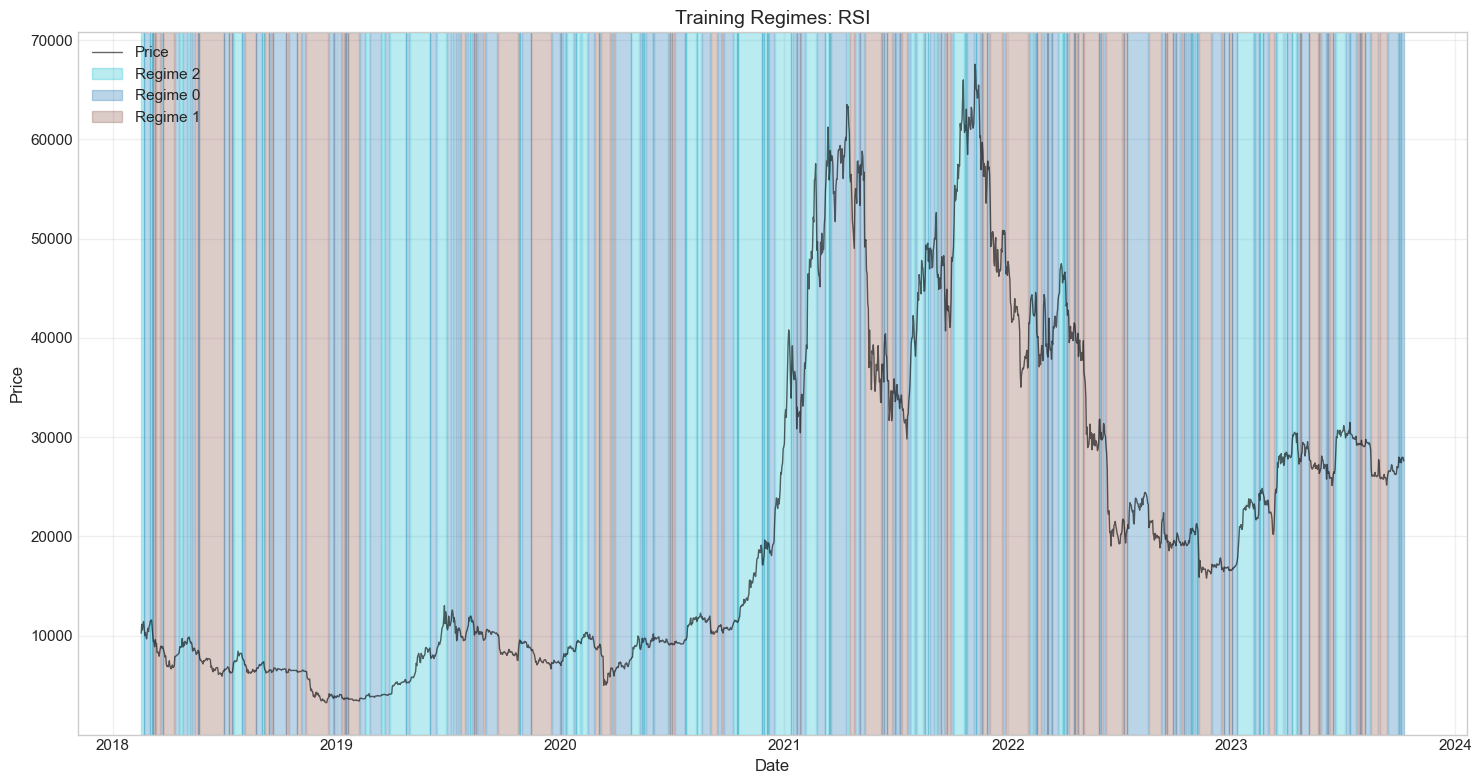

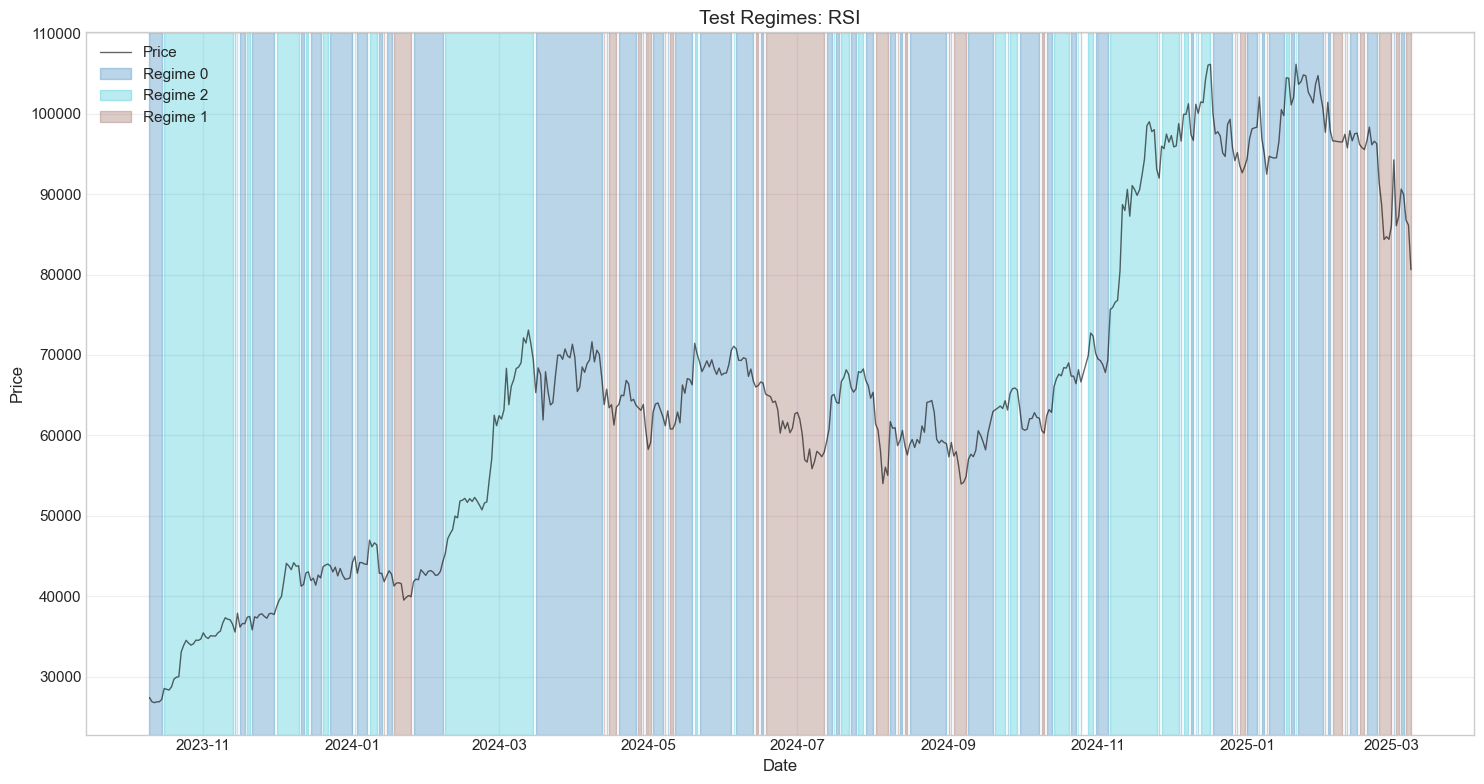

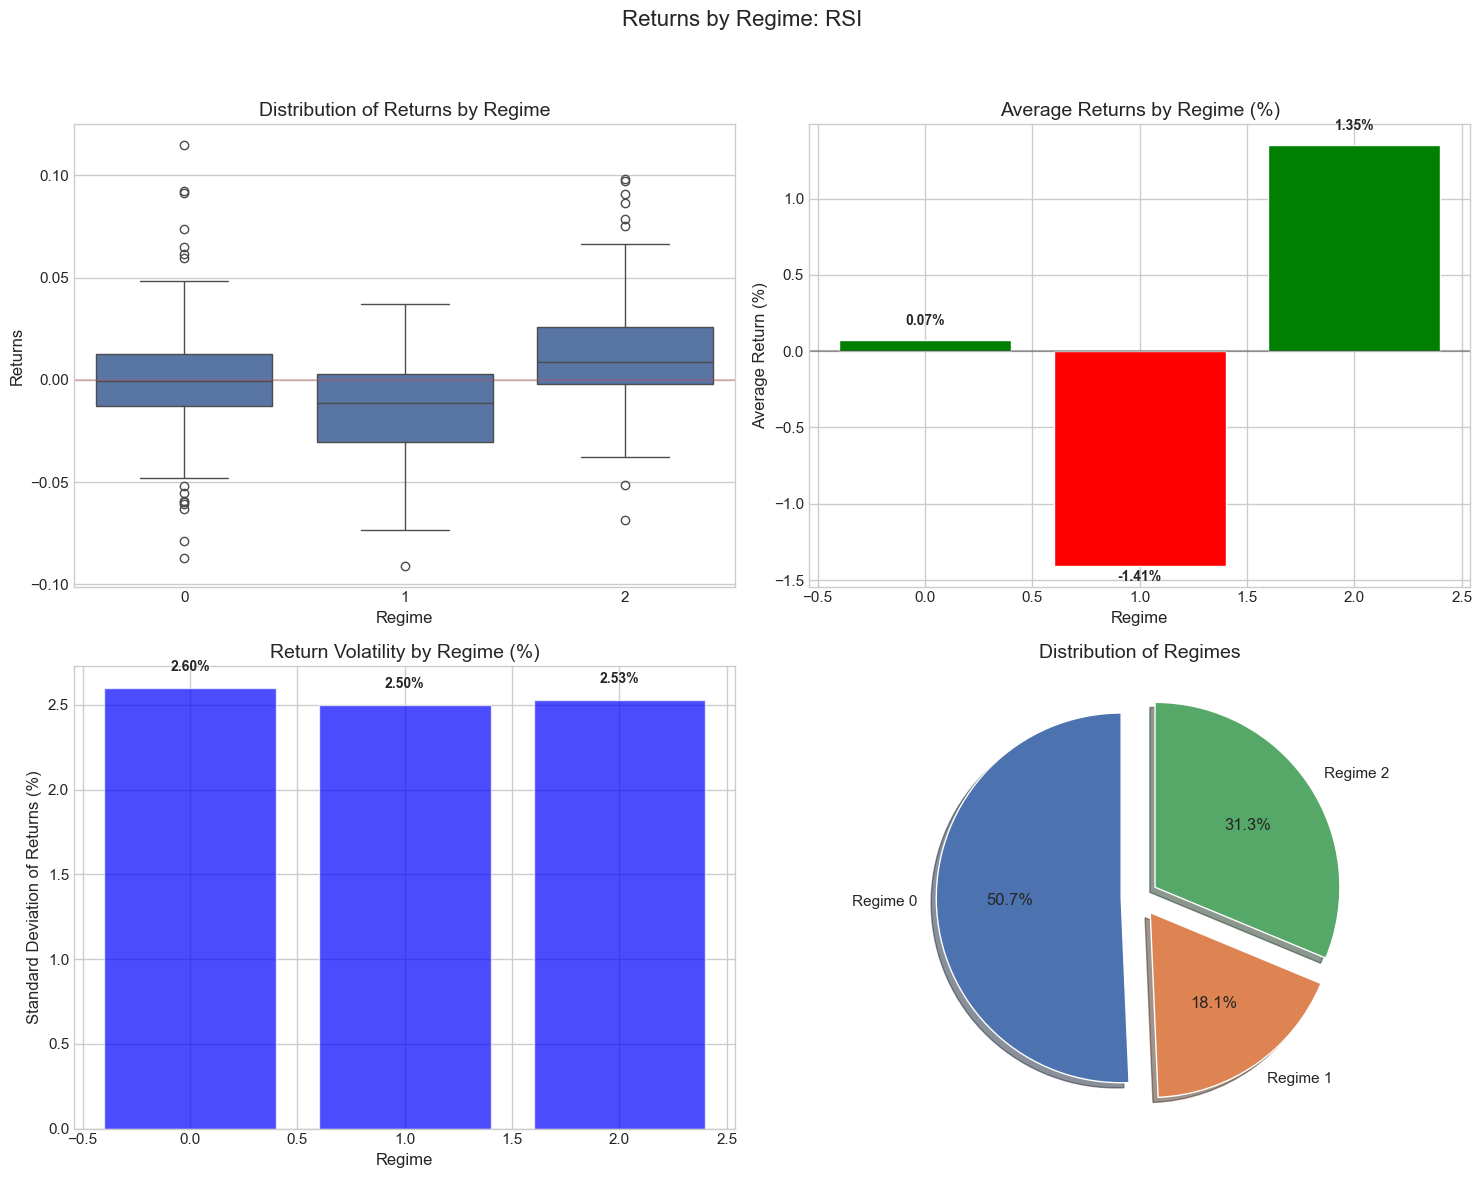

In [8]:
# Main execution script
if __name__ == "__main__":
    # Select features for analysis
    selected_columns = ['Returns', 'Range', 'Log_Range', 'pct_Range', 'fg', 'pct_fg', 'RSI', 'pct_RSI']
    print(f"\nSelected features for analysis: {selected_columns}")
    
    print("\n----- Creating Feature Combinations -----")
    # Create all possible feature combinations
    features = create_feature_combinations(selected_columns)
    print(f"Created {len(features)} feature combinations")
    
    # For demonstration or if computation is limited, you can use a subset of features
    # Uncomment the lines below to use a subset
    # feature_limit = 20  # Adjust based on your computational resources
    # features = features[:feature_limit]
    # print(f"Using a subset of {len(features)} feature combinations for analysis")
    
    print("\n----- Training PyTorch DNN-HMM Models -----")
    # Train PyTorch DNN-HMM models
    pytorch_dnn_hmm_models = train_pytorch_dnn_hmm_model(
        X_train, 
        X_train_scaled, 
        features,
        model_name="PyTorchDNNHMM",
        n_states=3,                 # Using 3 regimes (typically bearish, neutral, bullish)
        hidden_dims=[32, 16],       # Neural network architecture
        embedding_dim=8,            # Embedding dimension
        epochs=50,                  # Number of training epochs
        batch_size=32               # Batch size for training
    )
    
    # Create dummy HMM object for potential integration with existing visualizer
    dnn_hmm = create_dummy_hmm_object(pytorch_dnn_hmm_models)
    
    print("\n----- Finding Best Models -----")
    # Get best models based on silhouette score
    best_models = get_best_models(pytorch_dnn_hmm_models, metric='silhouette_score', top_n=3)
    print("Best models by silhouette score:")
    for i, (model_id, score) in enumerate(best_models):
        feature_list = pytorch_dnn_hmm_models[model_id]['features']
        scaling = pytorch_dnn_hmm_models[model_id]['scaling']
        print(f"{i+1}. {model_id}: score={score:.4f}, features={feature_list}, scaling={scaling}")
    
    # Get best models based on log-likelihood
    best_likelihood_models = get_best_models(pytorch_dnn_hmm_models, metric='log_likelihood', top_n=3)
    print("\nBest models by log-likelihood:")
    for i, (model_id, score) in enumerate(best_likelihood_models):
        feature_list = pytorch_dnn_hmm_models[model_id]['features']
        scaling = pytorch_dnn_hmm_models[model_id]['scaling']
        print(f"{i+1}. {model_id}: log-likelihood={score:.4f}, features={feature_list}, scaling={scaling}")
    
    print("\n----- Making Predictions with Best Model -----")
    # Make predictions with the best model
    if best_models:
        best_model_id = best_models[0][0]
        best_features = pytorch_dnn_hmm_models[best_model_id]['features']
        print(f"Using model {best_model_id} with features: {best_features}")
        
        # Make predictions
        predictions = predict_with_model(pytorch_dnn_hmm_models, best_model_id, X_test)
        
        # Visualize regimes
        print("\n----- Visualizing Regimes -----")
        
        # Training data regimes
        print("Visualizing training regimes...")
        train_regimes = pytorch_dnn_hmm_models[best_model_id]['regimes']
        train_fig = visualize_regimes(train_regimes, train_price, 
                                      title=f"Training Regimes: {'+'.join(best_features)}")
        
        # Save the figure
        train_filename = f"dnn_hmm_output/train_regimes_{'+'.join(best_features)}.png"
        train_fig.savefig(train_filename, dpi=300, bbox_inches='tight')
        print(f"Saved training regimes visualization to {train_filename}")
        
        # Test data regimes
        print("Visualizing test regimes...")
        test_fig = visualize_regimes(predictions, test_price, 
                                    title=f"Test Regimes: {'+'.join(best_features)}")
        
        # Save the figure
        test_filename = f"dnn_hmm_output/test_regimes_{'+'.join(best_features)}.png"
        test_fig.savefig(test_filename, dpi=300, bbox_inches='tight')
        print(f"Saved test regimes visualization to {test_filename}")
        
        # Analyze returns by regime
        print("\n----- Analyzing Returns by Regime -----")
        returns_fig = analyze_returns_by_regime(X_test, predictions, 
                                             title=f"Returns by Regime: {'+'.join(best_features)}")
        
        # Save the returns analysis
        returns_filename = f"dnn_hmm_output/returns_by_regime_{'+'.join(best_features)}.png"
        returns_fig.savefig(returns_filename, dpi=300, bbox_inches='tight')
        print(f"Saved returns analysis to {returns_filename}")
        
        # Count regime distribution
        regime_counts = pd.Series(predictions).value_counts().sort_index()
        print("\nTest Data Regime Distribution:")
        for regime, count in regime_counts.items():
            print(f"  Regime {regime}: {count} samples ({count/len(predictions)*100:.1f}%)")
        
        # Calculate average returns by regime
        regime_returns = pd.DataFrame({'Regime': predictions, 'Returns': X_test['Returns']})
        avg_returns = regime_returns.groupby('Regime')['Returns'].mean() * 100  # Convert to percentage
        
        print("\nAverage Returns by Regime:")
        for regime, avg_return in avg_returns.items():
            print(f"  Regime {regime}: {avg_return:.4f}%")
    else:
        print("No valid models found")
    
    # Export results to CSV
    print("\n----- Exporting Results -----")
    export_results(pytorch_dnn_hmm_models, "dnn_hmm_output/pytorch_dnn_hmm_results.csv")
    
    print("\n----- Analysis Complete -----")
    print("All files have been saved to the 'dnn_hmm_output' directory.")

### Conclusion 
Our DNN-HMM model for the RSI index provides the highest silhouette score of 0.6206, without scaling the data. The RSI index takes values from 0 till 100. The regimes where accurately captured, something that we can validate by our return table.

Test Data Regime Distribution:
  Regime 0: 261 samples (50.7%)
  Regime 1: 93 samples (18.1%)
  Regime 2: 161 samples (31.3%)

Average Returns by Regime:
  Regime 0: 0.0725%
  Regime 1: -1.4057%
  Regime 2: 1.3486%

DNNs need large ammounts of data, which isnt that easy when it comes to financial data. For example the Fear and Greed Index, which our best Standard HMM model used, is only available for a daily timeframe. Good news is that the RSI index can be used for smaller intervals, e.g. 1m time table.

A trading strategy that comes in mind is to open a long position when we are in Regime 2 and open a short position when we are in regime 1. We close the positions once the regime changes. Our model does seem to be overfitting over noise, constantly changing regimes. This creates a problem with our strategy where, in some cases, the open price for regime 2 is higher than the close price, and vice versa for regime 1. This is especially prominent for small regime periods. 

One way of reducing noise is to use an EMA, increase the RSI period from 14, or do both.